In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
data = pd.read_csv("mahadbt_dataset_with_outliers.csv")


In [34]:
data.head()

,Scholarship_Name,Gender,Caste,Religion,Education,Income,ExServicemen,Disability,Sports,Percentage,Status
0,Govt. of India Post-Matric Scholarship,Female,SC,Hindu,PhD,563780,No,Yes,Yes,59.86,Eligible
1,Govt. of India Post-Matric Scholarship,Male,SC,Hindu,HSC,251915,No,No,No,44.87,Not Eligible
2,Rajarshi Chhatrapati Shahu Maharaj EBC Scheme,Female,EWS,Hindu,SSC,352446,No,No,No,57.23,Eligible
3,Post Matric Scholarship to VJNT Students,Male,VJNT,Hindu,PhD,949039,No,No,No,85.77,Not Eligible
4,State Minority Scholarship Part II,Female,Open,Buddhist,SSC,1138347,No,No,No,89.55,Not Eligible


In [35]:
data.describe()

,Income,Percentage
count,5.000000e+03,5000.000000
mean,6.729096e+05,69.896718
std,1.726161e+06,26.475935
min,-5.000000e+05,-50.500000
25%,3.237382e+05,54.760000
50%,6.249495e+05,69.830000
75%,9.235110e+05,84.122500
max,1.000000e+08,1000.000000


In [36]:
dataColumns = data.columns
print(dataColumns)

Index(['Scholarship_Name', 'Gender', 'Caste', 'Religion', 'Education',
       'Income', 'ExServicemen', 'Disability', 'Sports', 'Percentage',
       'Status'],
      dtype='object')


In [37]:
numeric_cols = ['Income', 'Percentage']

categorical_cols = [
    'Scholarship_Name',
    'Gender',
    'Caste',
    'Religion',
    'Education',
    'ExServicemen',
    'Disability',
    'Sports'
]

In [38]:
print("Unique values in each column: ")
print()
for column in categorical_cols:
    print(f"{column}: {data[column].unique()}")
    print()

Unique values in each column: 

Scholarship_Name: ['Govt. of India Post-Matric Scholarship'
 'Rajarshi Chhatrapati Shahu Maharaj EBC Scheme'
 'Post Matric Scholarship to VJNT Students'
 'State Minority Scholarship Part II'
 'Post Matric Scholarship to OBC Students'
 'Post Matric Scholarship to SBC Students'
 'Education Concession to Children of Ex-Servicemen']

Gender: ['Female' 'Male']

Caste: ['SC' 'EWS' 'VJNT' 'Open' 'OBC' 'SBC' 'ST']

Religion: ['Hindu' 'Buddhist' 'Sikh' 'Christian' 'Jain' 'Muslim']

Education: ['PhD' 'HSC' 'SSC' 'Diploma' 'Postgraduate' 'Undergraduate']

ExServicemen: ['No' 'Yes']

Disability: ['Yes' 'No']

Sports: ['Yes' 'No']



In [41]:
print(data['Status'].value_counts())

Status
Eligible        2732
Not Eligible    2268
Name: count, dtype: int64


In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Scholarship_Name  5000 non-null   object 
 1   Gender            5000 non-null   object 
 2   Caste             5000 non-null   object 
 3   Religion          5000 non-null   object 
 4   Education         5000 non-null   object 
 5   Income            5000 non-null   int64  
 6   ExServicemen      5000 non-null   object 
 7   Disability        5000 non-null   object 
 8   Sports            5000 non-null   object 
 9   Percentage        5000 non-null   float64
 10  Status            5000 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 429.8+ KB


## Data Encoding

In [43]:
from sklearn.preprocessing import LabelEncoder


encoders = {}   # CREATE DICTIONARY HERE

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le   # SAVE EACH ENCODER

In [44]:
data.head()

,Scholarship_Name,Gender,Caste,Religion,Education,Income,ExServicemen,Disability,Sports,Percentage,Status
0,1,0,4,2,2,563780,0,1,1,59.86,Eligible
1,1,1,4,2,1,251915,0,0,0,44.87,Not Eligible
2,5,0,0,2,4,352446,0,0,0,57.23,Eligible
3,4,1,6,2,2,949039,0,0,0,85.77,Not Eligible
4,6,0,2,0,4,1138347,0,0,0,89.55,Not Eligible


## Finding Outleirs

In [45]:
def checkOutliers(data, col):
    plt.figure(figsize=(12,4))
    
    # Boxplot
    plt.subplot(1,2,1)
    plt.boxplot(data[col])
    plt.title(f"Boxplot of {col}")
    
    # Histogram 
    plt.subplot(1,2,2)
    sns.histplot(data=data, x=col, kde=True)
    
    mean = data[col].mean()
    std = data[col].std()
    
    plt.axvline(mean + 3*std, color='red')
    plt.axvline(mean - 3*std, color='red')
    
    plt.tight_layout()
    plt.show()


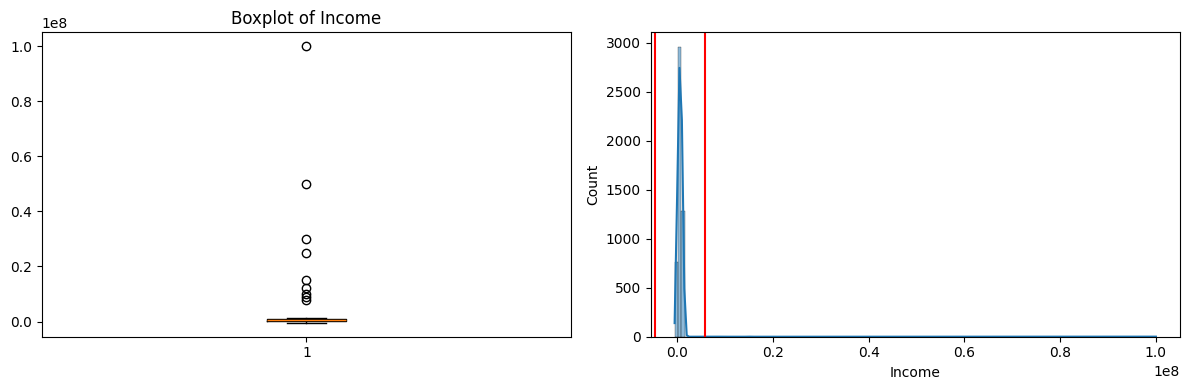

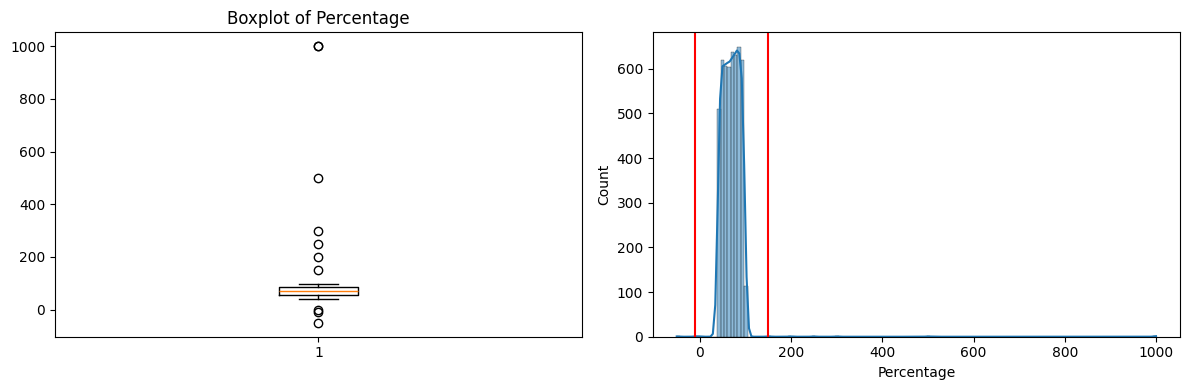

In [46]:
for col in numeric_cols:
    checkOutliers(data, col)

## Handle Outleirs

In [47]:
def handleOutliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data.loc[data[col] > upper, col] = upper
    data.loc[data[col] < lower, col] = lower

    checkOutliers(data, col)

C:\Users\Shrinath Arun Oulkar\AppData\Local\Temp\ipykernel_32896\612075595.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1823170.125' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[col] > upper, col] = upper


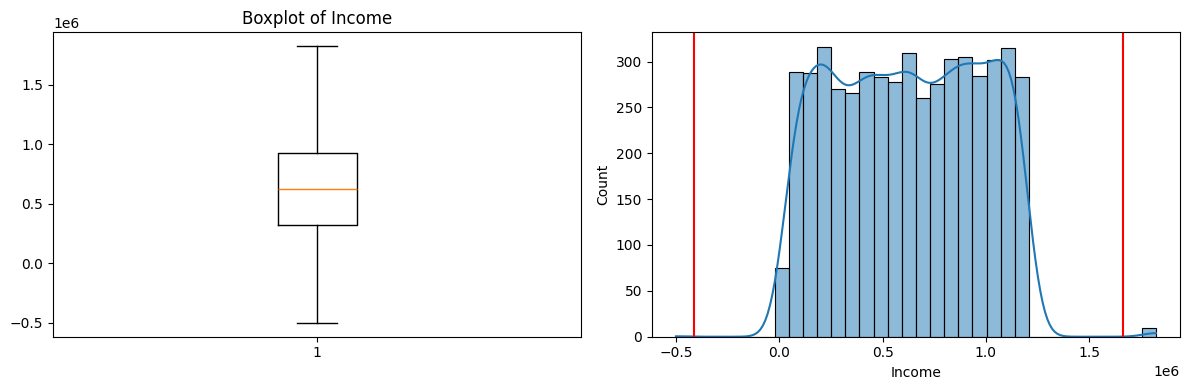

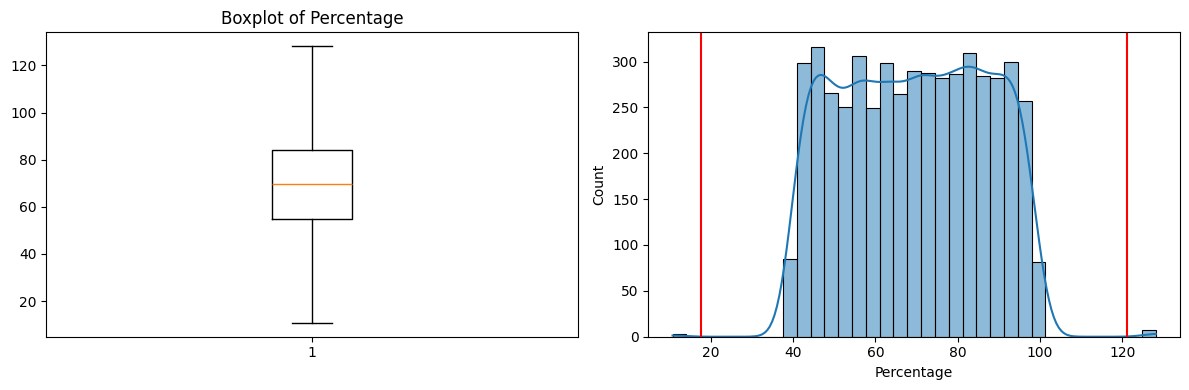

In [48]:
for col in numeric_cols:
    handleOutliers(data ,col)

## Correlation

In [51]:
# plt.figure(figsize=(20,15))
# sns.heatmap(data.corr(), annot=True)
# plt.show()

## Spliting Data

In [53]:
X = data.drop(['Status'], axis=1)
y = data['Status']

In [54]:
from sklearn.model_selection import train_test_split

In [55]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3500, 10)
X_test shape: (1500, 10)
y_train shape: (3500,)
y_test shape: (1500,)


## Handled Imbalanced Data

In [56]:
y.value_counts()

Status
Eligible        2732
Not Eligible    2268
Name: count, dtype: int64

In [57]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
X_train, y_train = sm.fit_resample(X_train, y_train)


In [58]:
print("Before SMOTE:")
print(y.value_counts())

print("After SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Status
Eligible        2732
Not Eligible    2268
Name: count, dtype: int64
After SMOTE:
Status
Not Eligible    1938
Eligible        1938
Name: count, dtype: int64


## Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)
param_grid_rf = { "n_estimators": [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200],
                  "criterion": ["gini", "entropy"]}
grid_search_rf = GridSearchCV( estimator=rf, param_grid=param_grid_rf, n_jobs=-1)
grid_search_rf.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [60]:
print("Best n_estimators:", grid_search_rf.best_params_)

Best n_estimators: {'criterion': 'gini', 'n_estimators': 100}


### Cross Validation for Random Forest

In [61]:
from sklearn.model_selection import cross_validate

In [62]:
rf = RandomForestClassifier(criterion='gini', n_estimators=100)
acc_cross_rf = cross_validate(rf, X_train, y_train)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [63]:
acc_cross_rf['test_score'].mean()

np.float64(0.9971619554373129)

In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [65]:
test_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(y_test, test_pred))

Random Forest Accuracy: 0.9966666666666667

Confusion Matrix:
[[789   5]
 [  0 706]]

Classification Report:
              precision    recall  f1-score   support

    Eligible       1.00      0.99      1.00       794
Not Eligible       0.99      1.00      1.00       706

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [66]:
print(f"Training Accuracy : ",rf.score(X_train, y_train))
print(f"Testing Accuracy : ",rf.score(X_test, y_test))

Training Accuracy :  1.0
Testing Accuracy :  0.9966666666666667


In [67]:
# import joblib

# # Save trained Random Forest model
# joblib.dump(rf, "scholarship_model.pkl")

# # Save encoders dictionary
# joblib.dump(encoders, "encoders.pkl")

# # Save feature column order
# joblib.dump(X.columns, "columns.pkl")

# print("✅ Model, Encoders, and Columns saved successfully!")

✅ Model, Encoders, and Columns saved successfully!


In [ ]:
# # ===============================
# # USER INPUT FOR MODEL TESTING
# # ===============================

# print("\nEnter Applicant Details:\n")

# user_data = {}

# for col in X.columns:
    
#     if col in encoders:   # categorical columns
        
#         print(f"\nPossible values for {col}:")
#         print(encoders[col].classes_)   # show valid options
        
#         value = input(f"Enter {col}: ")
#         value = encoders[col].transform([value])[0]
    
#     else:   # numerical columns
        
#         value = float(input(f"Enter {col}: "))
    
#     user_data[col] = value

# # Convert into DataFrame
# import pandas as pd
# user_df = pd.DataFrame([user_data])

# # Predict
# prediction = rf.predict(user_df)

# if prediction[0] == 1:
#     print("\n✅ The Applicant is ELIGIBLE for Scholarship")
# else:
#     print("\n❌ The Applicant is NOT ELIGIBLE for Scholarship")